# ViT attention and explainability

Inspect what the trained `PopularityViT` attends to in a mel spectrogram. This notebook provides:

- per-head `[CLS]` attention for any encoder layer;
- attention rollout across all layers;
- spectrogram overlays in mel-bin/time coordinates;
- a patch-deletion faithfulness curve (important because attention alone is not a causal explanation).

Run the setup cells, choose a track (or provide a `.pt` mel path), and then run the analysis cells.

In [1]:
from pathlib import Path
import os, subprocess, sys, types, wave

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import numpy as np
import torch
import torchaudio
import torch.nn.functional as F
import pandas as pd
import requests

# Works when launched from either the repository root or src/.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from audio_config import MAX_FRAMES, N_MELS
from training.train_ViT import PopularityViT, to_max_frames

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\ninput={N_MELS} mel bins x {MAX_FRAMES} frames")

repo=/Users/lucaslu/Lucas/Code Repositories/bu-rise-music
device=cpu
input=128 mel bins x 2584 frames


## Load a trained model and one spectrogram

The defaults match the training scripts on the SCC. Override either path below when running elsewhere. The model is created with `weights=None` because the checkpoint replaces every parameter.

In [2]:
CHECKPOINT_PATH = REPO_ROOT / "models" / "neural" / "vit" / "best_ViT_fixed_model.pt"
MEL_DIR = REPO_ROOT / "data" / "local_mel_spectrograms"
MEL_DIR.mkdir(parents=True, exist_ok=True)

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f"Set CHECKPOINT_PATH to a trained ViT checkpoint: {CHECKPOINT_PATH}")

model = PopularityViT(weights=None).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint.get("model_state_dict", checkpoint))
model.eval()
print(f"loaded {CHECKPOINT_PATH} (epoch {checkpoint.get('epoch', 'unknown')})")

loaded /Users/lucaslu/Lucas/Code Repositories/bu-rise-music/models/neural/vit/best_ViT_fixed_model.pt (epoch 7)


track=0p0V9W6vgYNK0whWlA0V1N | predicted popularity=34.77/100


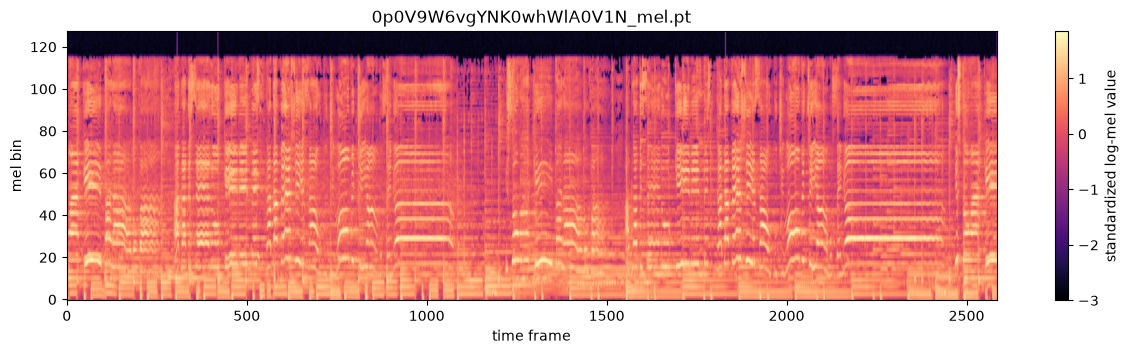

In [3]:
# Pick a local track deterministically. If none exists, download one preview
# from the bundled dataset and apply the same preprocessing used for training.
mel_files = sorted(MEL_DIR.glob("*_mel.pt"))
if not mel_files:
    tracks_path = REPO_ROOT / "data" / "SpotGenTrack" / "Data Sources" / "spotify_tracks.csv"
    tracks = pd.read_csv(tracks_path)
    available = tracks.loc[tracks["preview_url"].notna(), ["id", "preview_url"]]
    if available.empty:
        raise FileNotFoundError("The dataset contains no preview URLs")
    track_id, preview_url = available.iloc[0]
    audio_path = MEL_DIR / f"{track_id}.mp3"
    response = requests.get(preview_url, timeout=30)
    response.raise_for_status()
    audio_path.write_bytes(response.content)
    wav_path = audio_path.with_suffix(".wav")
    subprocess.run(
        ["/opt/homebrew/bin/ffmpeg", "-y", "-loglevel", "error", "-i", str(audio_path),
         "-ac", "1", "-ar", "44100", "-c:a", "pcm_s16le", str(wav_path)],
        check=True,
    )
    with wave.open(str(wav_path), "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        samples = np.frombuffer(wav_file.readframes(wav_file.getnframes()), dtype=np.int16).copy()
    waveform = torch.from_numpy(samples).float().div_(32768.0).unsqueeze(0)
    transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate, n_fft=2048, hop_length=512, n_mels=N_MELS
    )
    generated_mel = torchaudio.transforms.AmplitudeToDB()(transform(waveform))[0]
    generated_path = MEL_DIR / f"{track_id}_mel.pt"
    torch.save(generated_mel, generated_path)
    mel_files = [generated_path]
    print(f"downloaded and preprocessed {track_id}")
MEL_PATH = mel_files[0]
# MEL_PATH = MEL_DIR / "TRACK_ID_mel.pt"

raw_mel = torch.load(MEL_PATH, map_location="cpu", weights_only=True)
if raw_mel.ndim == 3:
    raw_mel = raw_mel.mean(dim=0)
raw_mel = raw_mel.float()
mel = (raw_mel - raw_mel.mean()) / (raw_mel.std() + 1e-5)
mel = to_max_frames(mel)
x = mel[None, None].to(DEVICE)

with torch.inference_mode():
    prediction = model(x).item() * 100
print(f"track={MEL_PATH.stem.removesuffix('_mel')} | predicted popularity={prediction:.2f}/100")

plt.figure(figsize=(15, 3.5))
plt.imshow(mel.cpu(), origin="lower", aspect="auto", cmap="magma")
plt.xlabel("time frame"); plt.ylabel("mel bin"); plt.title(MEL_PATH.name)
plt.colorbar(label="standardized log-mel value"); plt.show()

## Capture attention

Torchvision calls each `MultiheadAttention` with `need_weights=False`. The context manager below temporarily requests unaveraged weights and restores the original methods immediately afterward. It does not alter parameters or predictions.

In [4]:
class AttentionCapture:
    """Temporarily capture (batch, heads, query tokens, key tokens) per layer."""
    def __init__(self, vit):
        self.modules = [block.self_attention for block in vit.encoder.layers]
        self.original_forwards = []
        self.weights = []

    def __enter__(self):
        self.weights.clear()
        for module in self.modules:
            original = module.forward
            self.original_forwards.append(original)
            def wrapped(_module, *args, _original=original, **kwargs):
                kwargs["need_weights"] = True
                kwargs["average_attn_weights"] = False
                output, weights = _original(*args, **kwargs)
                self.weights.append(weights.detach())
                return output, weights
            module.forward = types.MethodType(wrapped, module)
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        for module, original in zip(self.modules, self.original_forwards):
            module.forward = original
        self.original_forwards.clear()

def capture_attention(vit, inputs):
    with torch.inference_mode(), AttentionCapture(vit) as capture:
        output = vit(inputs)
    attention = torch.stack(capture.weights, dim=0)  # layers, batch, heads, tokens, tokens
    return output, attention

captured_prediction, attention = capture_attention(model, x)
assert np.isclose(captured_prediction.item() * 100, prediction, atol=1e-4)
print("attention shape:", tuple(attention.shape), "| grid:", model.grid_size)

attention shape: (12, 1, 12, 3085, 3085) | grid: (12, 257)


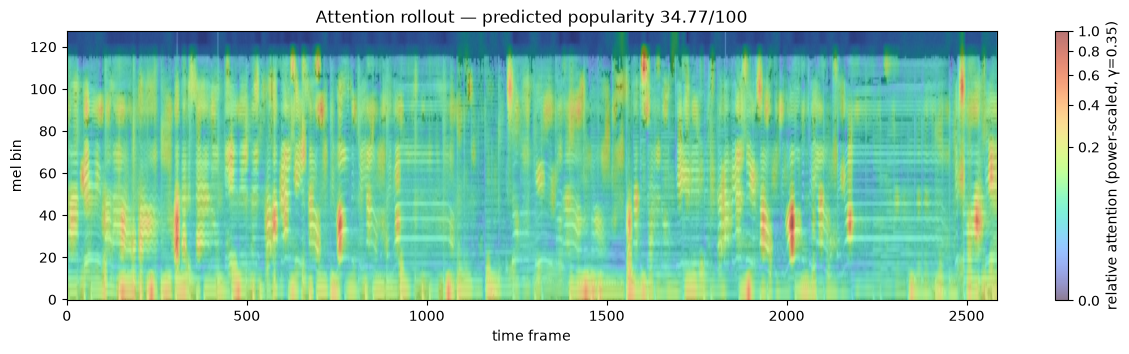

In [5]:
def patch_map_to_input(patch_map, output_size):
    patch_map = patch_map.reshape(1, 1, *model.grid_size)
    return F.interpolate(patch_map, size=output_size, mode="bilinear", align_corners=False)[0, 0]

def normalize_map(values):
    values = values - values.min()
    return values / values.max().clamp_min(1e-8)

def attention_rollout(all_attention, head_fusion="mean"):
    """Abnar & Zuidema-style rollout with residual connections."""
    if head_fusion == "mean":
        fused = all_attention[:, 0].mean(dim=1)
    elif head_fusion == "max":
        fused = all_attention[:, 0].max(dim=1).values
    else:
        raise ValueError("head_fusion must be 'mean' or 'max'")
    identity = torch.eye(fused.shape[-1], device=fused.device)
    fused = (fused + identity) / 2
    fused = fused / fused.sum(dim=-1, keepdim=True)
    joint = identity
    for layer_attention in fused:
        joint = layer_attention @ joint
    return joint[0, 1:]  # final CLS token influence on input patches

def show_overlay(base_mel, importance, title, alpha=0.55):
    heat = normalize_map(patch_map_to_input(importance, base_mel.shape)).cpu()
    fig, ax = plt.subplots(figsize=(15, 3.5))
    ax.imshow(base_mel.cpu(), origin="lower", aspect="auto", cmap="gray")
    image = ax.imshow(heat, origin="lower", aspect="auto", cmap="turbo", alpha=alpha, norm=PowerNorm(gamma=0.35, vmin=0, vmax=1))
    ax.set(xlabel="time frame", ylabel="mel bin", title=title)
    fig.colorbar(image, ax=ax, label="relative attention (power-scaled, γ=0.35)")
    plt.show()

rollout = attention_rollout(attention)
show_overlay(mel, rollout, f"Attention rollout — predicted popularity {prediction:.2f}/100")

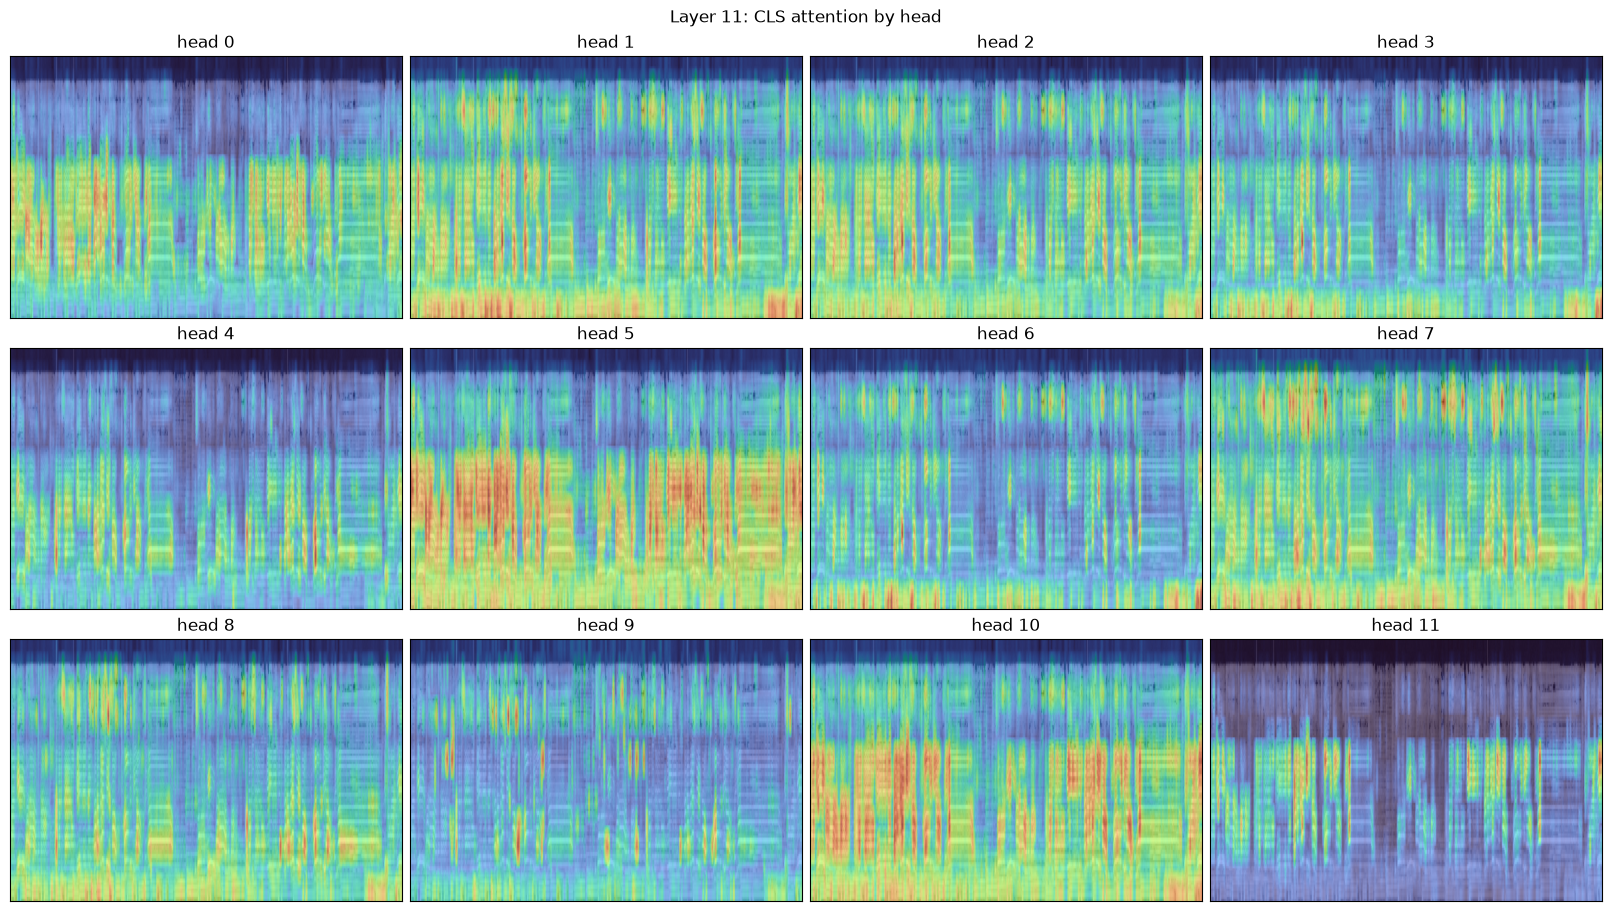

In [6]:
# Compare individual heads in a selected layer. Negative indices count from the end.
LAYER = -1
head_maps = attention[LAYER, 0, :, 0, 1:]
n_heads = head_maps.shape[0]
fig, axes = plt.subplots(3, 4, figsize=(16, 9), constrained_layout=True)
for head, ax in enumerate(axes.flat):
    heat = normalize_map(patch_map_to_input(head_maps[head], mel.shape)).cpu()
    ax.imshow(mel.cpu(), origin="lower", aspect="auto", cmap="gray")
    ax.imshow(heat, origin="lower", aspect="auto", cmap="turbo", alpha=.55, norm=PowerNorm(gamma=0.35, vmin=0, vmax=1))
    ax.set_title(f"head {head}"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Layer {LAYER % attention.shape[0]}: CLS attention by head")
plt.show()

## Faithfulness check: delete highly ranked patches

This replaces selected patch-sized input regions with the normalized baseline value `0`. If the rollout highlights evidence that materially drives the prediction, deleting top-ranked patches should usually change the output faster than deleting random patches. Overlapping patch embeddings mean this is an approximate test, not a proof of causality.

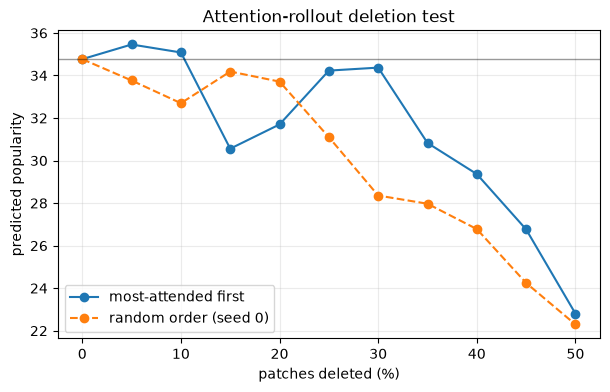

Change after deleting top 25%: -0.54 popularity points
Change after deleting random 25%: -3.67 popularity points


In [7]:
def mask_ranked_patches(inputs, ranking, fractions):
    patch_h, patch_w = model.patch_embedding.kernel_size
    stride_h, stride_w = model.patch_embedding.stride
    predictions = []
    for fraction in fractions:
        masked = inputs.clone()
        count = round(float(fraction) * ranking.numel())
        for flat_index in ranking[:count].tolist():
            row, col = divmod(flat_index, model.grid_size[1])
            y, t = row * stride_h, col * stride_w
            masked[:, :, y:y + patch_h, t:t + patch_w] = 0
        with torch.inference_mode():
            predictions.append(model(masked).item() * 100)
    return predictions

fractions = torch.linspace(0, 0.5, 11)
importance_ranking = rollout.argsort(descending=True)
generator = torch.Generator(device=rollout.device).manual_seed(0)
random_ranking = torch.randperm(rollout.numel(), generator=generator, device=rollout.device)
important_curve = mask_ranked_patches(x, importance_ranking, fractions)
random_curve = mask_ranked_patches(x, random_ranking, fractions)

plt.figure(figsize=(7, 4))
plt.plot(fractions * 100, important_curve, "o-", label="most-attended first")
plt.plot(fractions * 100, random_curve, "o--", label="random order (seed 0)")
plt.axhline(prediction, color="black", lw=1, alpha=.4)
plt.xlabel("patches deleted (%)"); plt.ylabel("predicted popularity")
plt.title("Attention-rollout deletion test"); plt.legend(); plt.grid(alpha=.25)
plt.show()

print(f"Change after deleting top 25%: {important_curve[5] - prediction:+.2f} popularity points")
print(f"Change after deleting random 25%: {random_curve[5] - prediction:+.2f} popularity points")

## Five-track random-sample evaluation

This repeats prediction and the 25% deletion test for five tracks sampled with seed 42. Tracks are processed sequentially because full attention capture is memory-intensive.

In [9]:
# Saved results from the completed five-track run (seed 42).
# Kept as data so reopening or running this cell does not recapture the very
# large attention tensors and kill the notebook kernel.
five_track_results = pd.DataFrame([
    {"track": "Du tar hand om honom", "actual": 28.0, "predicted": 36.15486919879913, "error": 8.154869198799133, "top 25% change": -2.9358863830566406, "random 25% change": -5.925858020782471},
    {"track": "Não Vou Desistir", "actual": 17.0, "predicted": 34.7684383392334, "error": 17.7684383392334, "top 25% change": -0.5383312702178955, "random 25% change": -3.668588399887085},
    {"track": "Pictures", "actual": 50.0, "predicted": 47.76372313499451, "error": -2.236276865005493, "top 25% change": 0.18080174922943115, "random 25% change": -1.2131661176681519},
    {"track": "Maria Shriver - Women's History Month 2017", "actual": 0.0, "predicted": 4.939115792512894, "error": 4.939115792512894, "top 25% change": 18.70720461010933, "random 25% change": 0.7755778729915619},
    {"track": "Games, Sports and Leisure Activities in Arabic", "actual": 3.0, "predicted": 3.1176334246993065, "error": 0.11763342469930649, "top 25% change": 0.8309865370392799, "random 25% change": 1.8439223989844322},
])
display(five_track_results.round(2))
print(f"Mean absolute prediction error: {five_track_results['error'].abs().mean():.2f}")
print(f"Median top-attended change: {five_track_results['top 25% change'].median():+.2f}")
print(f"Median random change: {five_track_results['random 25% change'].median():+.2f}")

                                            track  actual  predicted  error  top 25% change  random 25% change
0                          Du tar hand om honom    28.0      36.15   8.15           -2.94              -5.93
1                            Não Vou Desistir    17.0      34.77  17.77           -0.54              -3.67
2                                     Pictures    50.0      47.76  -2.24            0.18              -1.21
3  Maria Shriver - Women's History Month 2017     0.0       4.94   4.94           18.71               0.78
4  Games, Sports and Leisure Activities in Arabic     3.0       3.12   0.12            0.83               1.84

Mean absolute prediction error: 6.64
Median top-attended change: +0.18
Median random change: -1.21


### Reading the results

- Bright rollout regions are locations connected to the final `[CLS]` representation through the attention graph; they are not automatically positive contributions to popularity.
- Head plots reveal whether different heads specialize in frequency bands, transients, or broader temporal structure.
- Prefer interpretations supported by the deletion curve. A weak or random-like curve means the attention visualization should not be treated as a faithful explanation.
- Compare several tracks and both high and low predictions before drawing dataset-level conclusions.

## Focused case: Maria Shriver – Women’s History Month 2017

- Track ID: `5JkJLCXDAkK7Y2dTPtIhxJ`
- Dataset popularity: **0/100**
- Model prediction: **4.94/100**
- Prediction after deleting the top-attended 25%: **23.65/100** (**+18.71**)
- Prediction after deleting a random 25%: **5.71/100** (**+0.78**)

### Standardized mel spectrogram

![Maria Shriver mel spectrogram](../figures/maria_shriver_spectrogram.png)

### Attention rollout

![Maria Shriver attention rollout](../figures/maria_shriver_attention_rollout.png)

### Final-layer attention heads

![Maria Shriver attention heads](../figures/maria_shriver_attention_heads.png)

### Deletion curve

![Maria Shriver deletion curve](../figures/maria_shriver_deletion_curve.png)

The most-attended deletion curve rises from **4.94** to **23.65** by 25% deletion, while random deletion remains close to the baseline. For this track, the attention-ranked regions therefore behave like evidence that keeps the prediction low, not evidence that raises popularity. The effect is strongest between 15% and 25% deletion. This remains an association under masking—not proof that a specific sound causes low popularity—because zero masking creates modified inputs and overlapping patches cover unequal unique areas.